# Bank Marketing Classification - Machine Learning Analysis

**Dataset:** UCI Bank Marketing Dataset (bank-full.csv)  
**Task:** Binary classification - Predict whether a client will subscribe to a term deposit  
**Algorithms:** Logistic Regression, K-Nearest Neighbors, Support Vector Machine, Random Forest, XGBoost

## 1. Imports and Setup

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate, GridSearchCV
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, accuracy_score, precision_score, recall_score,
    f1_score, ConfusionMatrixDisplay
)

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

print('All imports successful.')

All imports successful.


## 2. Data Loading and Exploration

In [15]:
df = pd.read_csv('bank-full.csv', sep=';')

print(f'Dataset shape: {df.shape}')
print(f'Number of features: {df.shape[1] - 1}')
print(f'Number of samples: {df.shape[0]}')
print()
df.head(10)

Dataset shape: (45211, 17)
Number of features: 16
Number of samples: 45211



,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
5,35,management,married,tertiary,no,231,yes,no,unknown,5,may,139,1,-1,0,unknown,no
6,28,management,single,tertiary,no,447,yes,yes,unknown,5,may,217,1,-1,0,unknown,no
7,42,entrepreneur,divorced,tertiary,yes,2,yes,no,unknown,5,may,380,1,-1,0,unknown,no
8,58,retired,married,primary,no,121,yes,no,unknown,5,may,50,1,-1,0,unknown,no
9,43,technician,single,secondary,no,593,yes,no,unknown,5,may,55,1,-1,0,unknown,no


In [16]:
print('=== Data Types ===')
print(df.dtypes)
print()
print('=== Missing Values ===')
print(df.isnull().sum())
print()
print('=== Statistical Summary (Numeric) ===')
df.describe()

=== Data Types ===
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object

=== Missing Values ===
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

=== Statistical Summary (Numeric) ===


,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [17]:
print('=== Categorical Feature Values ===')
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    print(f'\n{col}: {df[col].nunique()} unique values')
    print(df[col].value_counts())

=== Categorical Feature Values ===

job: 12 unique values
job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64

marital: 3 unique values
marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64

education: 4 unique values
education
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64

default: 2 unique values
default
no     44396
yes      815
Name: count, dtype: int64

housing: 2 unique values
housing
yes    25130
no     20081
Name: count, dtype: int64

loan: 2 unique values
loan
no     37967
yes     7244
Name: count, dtype: int64

contact: 3 unique values
contact
cellular     29285
unknown      13020
telephone     2906
Name: count, dtype: int64

month: 12 unique values


### 2.1 Target Variable Distribution

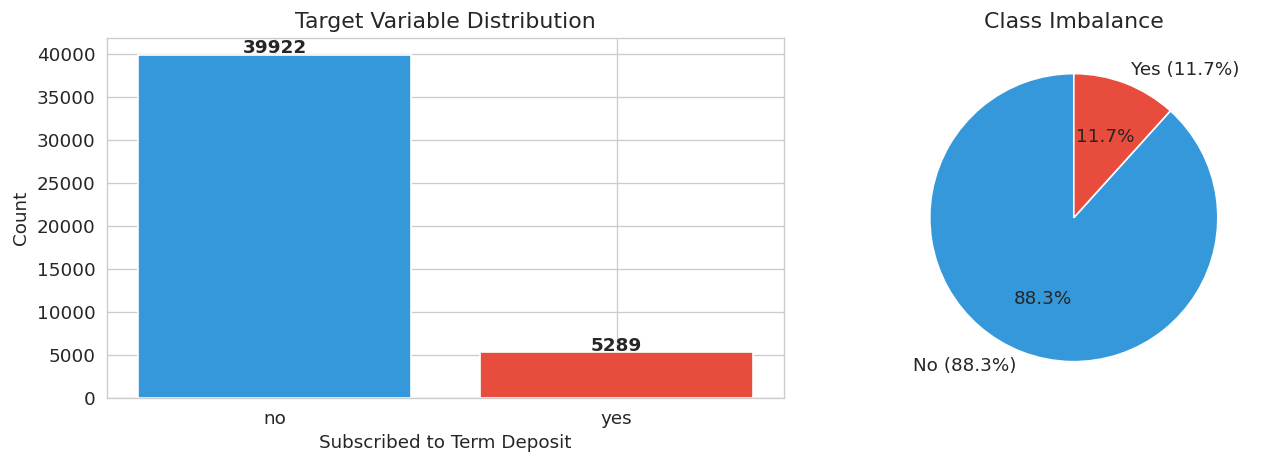

Imbalance ratio: 7.55:1


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
counts = df['y'].value_counts()
colors = ['#3498db', '#e74c3c']
axes[0].bar(counts.index, counts.values, color=colors)
axes[0].set_title('Target Variable Distribution')
axes[0].set_xlabel('Subscribed to Term Deposit')
axes[0].set_ylabel('Count')
for i, (idx, val) in enumerate(zip(counts.index, counts.values)):
    axes[0].text(i, val + 200, str(val), ha='center', fontweight='bold')

# Percentage pie
perc = df['y'].value_counts(normalize=True) * 100
axes[1].pie(perc.values, labels=[f'No ({perc.values[0]:.1f}%)', f'Yes ({perc.values[1]:.1f}%)'],
            colors=colors, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Class Imbalance')

plt.tight_layout()
plt.savefig('fig_class_distribution.png', bbox_inches='tight')
plt.show()

print(f'Imbalance ratio: {counts.values[0]/counts.values[1]:.2f}:1')

### 2.2 Feature Distributions

Numeric features: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']


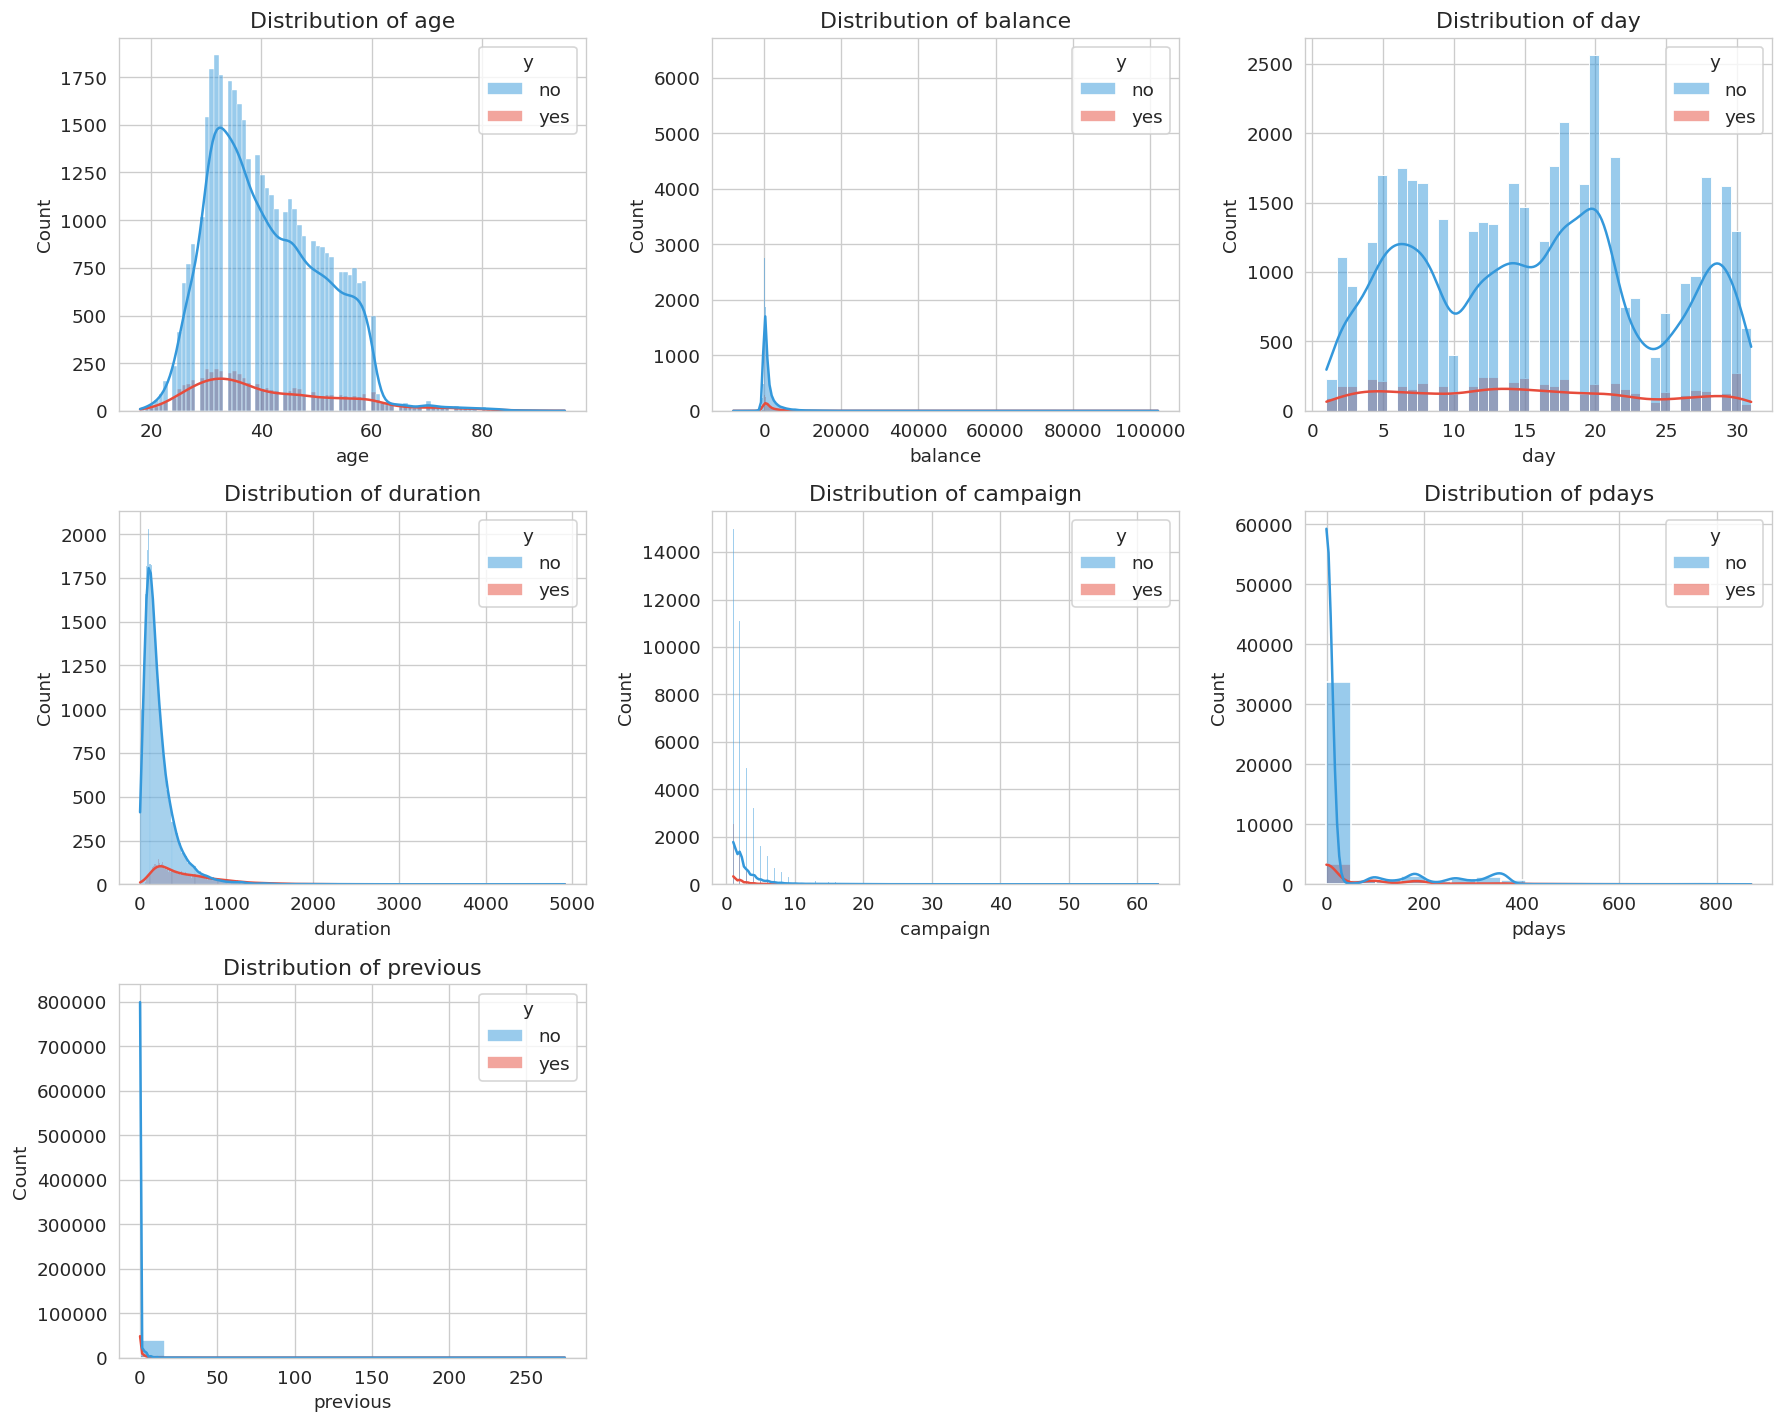

In [19]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f'Numeric features: {num_cols}')

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    if i < len(axes):
        sns.histplot(data=df, x=col, hue='y', kde=True, ax=axes[i], palette=colors)
        axes[i].set_title(f'Distribution of {col}')

# Hide unused axes
for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('fig_feature_distributions.png', bbox_inches='tight')
plt.show()

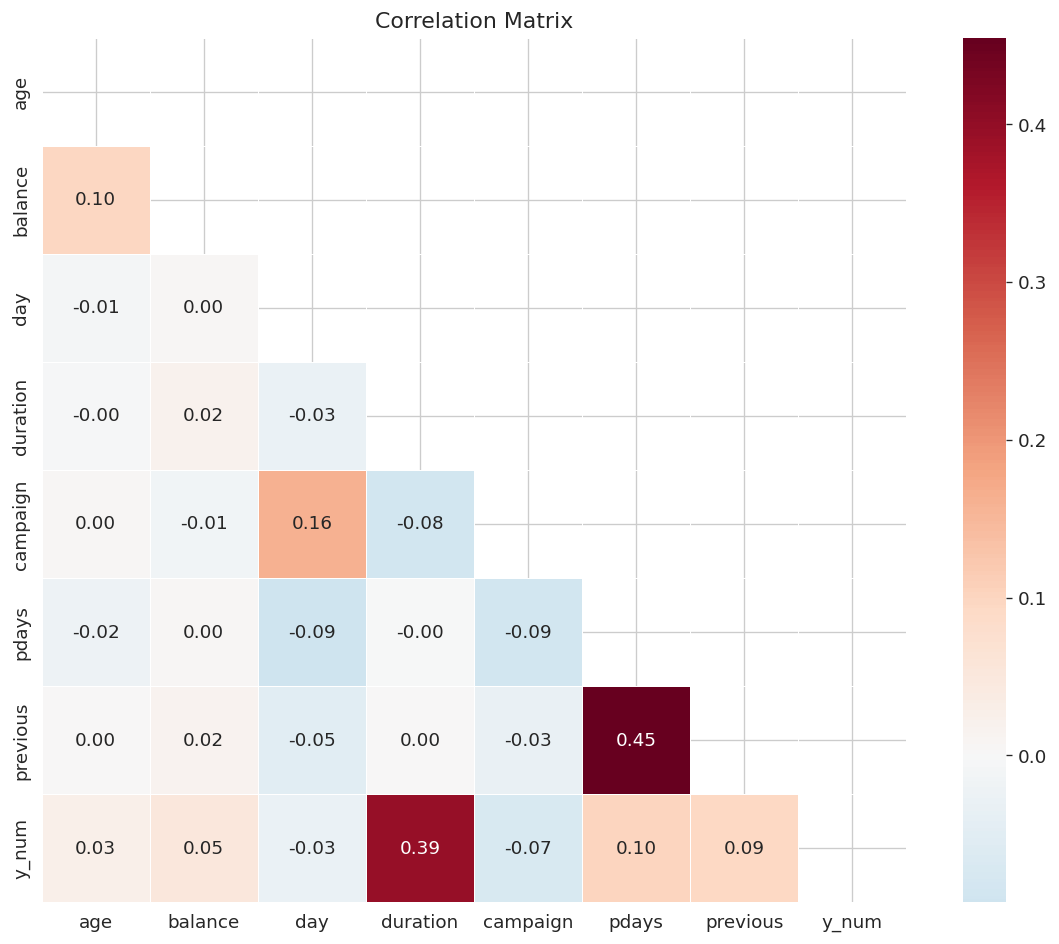

In [20]:
# Correlation matrix for numeric features
plt.figure(figsize=(10, 8))
df_temp = df.copy()
df_temp['y_num'] = (df_temp['y'] == 'yes').astype(int)
corr = df_temp[num_cols + ['y_num']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.savefig('fig_correlation_matrix.png', bbox_inches='tight')
plt.show()

## 3. Data Preprocessing

In [21]:
# Drop 'duration' as it is not known before a call is made (data leakage)
# As noted in the UCI dataset description:
# "duration: ... this attribute highly affects the output target ...
#  should only be included for benchmark purposes"

df_clean = df.drop(columns=['duration'])
print(f'Shape after dropping duration: {df_clean.shape}')
print(f'Remaining columns: {list(df_clean.columns)}')

Shape after dropping duration: (45211, 16)
Remaining columns: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'campaign', 'pdays', 'previous', 'poutcome', 'y']


In [22]:
# Encode target variable
le = LabelEncoder()
df_clean['y'] = le.fit_transform(df_clean['y'])  # no=0, yes=1
print(f'Target encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}')

# Separate features and target
X = df_clean.drop(columns=['y'])
y = df_clean['y']

print(f'\nFeature matrix shape: {X.shape}')
print(f'Target distribution:\n{y.value_counts()}')

Target encoding: {'no': np.int64(0), 'yes': np.int64(1)}

Feature matrix shape: (45211, 15)
Target distribution:
y
0    39922
1     5289
Name: count, dtype: int64


In [23]:
# Identify feature types
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print(f'Numeric features ({len(numeric_features)}): {numeric_features}')
print(f'Categorical features ({len(categorical_features)}): {categorical_features}')

# Build preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
    ]
)

print('\nPreprocessor built successfully.')

Numeric features (6): ['age', 'balance', 'day', 'campaign', 'pdays', 'previous']
Categorical features (9): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

Preprocessor built successfully.


In [25]:
# Train-test split (80/20 stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set:     {X_test.shape[0]} samples')
print(f'\nTraining target distribution:\n{y_train.value_counts()}')
print(f'\nTest target distribution:\n{y_test.value_counts()}')

Training set: 36168 samples
Test set:     9043 samples

Training target distribution:
y
0    31937
1     4231
Name: count, dtype: int64

Test target distribution:
y
0    7985
1    1058
Name: count, dtype: int64


## 4. Model Training and Evaluation

We evaluate 5 classifiers:
1. **Logistic Regression** (linear baseline)
2. **K-Nearest Neighbors** (instance-based)
3. **Support Vector Machine** (margin-based)
4. **Random Forest** (ensemble, bagging)
5. **XGBoost** (ensemble, boosting)

In [27]:
# Define models with class_weight='balanced' where applicable to handle imbalance
# Note: We use LinearSVC (much faster than kernel SVM on large datasets) wrapped
# with CalibratedClassifierCV to get probability estimates for ROC-AUC.
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=2000, class_weight='balanced', random_state=42
    ),
    'KNN': KNeighborsClassifier(
        n_neighbors=5
    ),
    'SVM (Linear)': CalibratedClassifierCV(
        LinearSVC(class_weight='balanced', max_iter=5000, random_state=42),
        cv=3
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200, scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
        eval_metric='logloss', random_state=42, n_jobs=-1
    )
}

print('Models defined:')
for name in models:
    print(f'  - {name}')

Models defined:
  - Logistic Regression
  - KNN
  - SVM (Linear)
  - Random Forest
  - XGBoost


### 4.1 Cross-Validation Comparison

In [28]:
# 5-fold stratified cross-validation on training data
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

cv_results = {}

for name, model in models.items():
    print(f'Cross-validating {name}...')
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    scores = cross_validate(
        pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=2
    )

    cv_results[name] = {
        'Accuracy': scores['test_accuracy'].mean(),
        'Precision': scores['test_precision'].mean(),
        'Recall': scores['test_recall'].mean(),
        'F1-Score': scores['test_f1'].mean(),
        'ROC-AUC': scores['test_roc_auc'].mean(),
        'Accuracy_std': scores['test_accuracy'].std(),
        'F1_std': scores['test_f1'].std(),
        'AUC_std': scores['test_roc_auc'].std()
    }
    print(f'  Accuracy: {cv_results[name]["Accuracy"]:.4f} (+/- {cv_results[name]["Accuracy_std"]:.4f})')
    print(f'  F1-Score: {cv_results[name]["F1-Score"]:.4f} (+/- {cv_results[name]["F1_std"]:.4f})')
    print(f'  ROC-AUC:  {cv_results[name]["ROC-AUC"]:.4f} (+/- {cv_results[name]["AUC_std"]:.4f})')
    print()

print('Cross-validation complete.')

Cross-validating Logistic Regression...
  Accuracy: 0.7547 (+/- 0.0055)
  F1-Score: 0.3727 (+/- 0.0031)
  ROC-AUC:  0.7636 (+/- 0.0032)

Cross-validating KNN...
  Accuracy: 0.8845 (+/- 0.0031)
  F1-Score: 0.2827 (+/- 0.0230)
  ROC-AUC:  0.6952 (+/- 0.0107)

Cross-validating SVM (Linear)...
  Accuracy: 0.8902 (+/- 0.0011)
  F1-Score: 0.2549 (+/- 0.0158)
  ROC-AUC:  0.7632 (+/- 0.0033)

Cross-validating Random Forest...
  Accuracy: 0.8935 (+/- 0.0014)
  F1-Score: 0.3062 (+/- 0.0160)
  ROC-AUC:  0.7792 (+/- 0.0042)

Cross-validating XGBoost...
  Accuracy: 0.8374 (+/- 0.0023)
  F1-Score: 0.4167 (+/- 0.0081)
  ROC-AUC:  0.7543 (+/- 0.0078)

Cross-validation complete.


In [29]:
# Cross-validation results table
cv_df = pd.DataFrame(cv_results).T
cv_display = cv_df[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']].round(4)
print('=== Cross-Validation Results (5-Fold Stratified) ===')
display(cv_display)

=== Cross-Validation Results (5-Fold Stratified) ===


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression,0.7547,0.2660,0.6228,0.3727,0.7636
KNN,0.8845,0.5171,0.1948,0.2827,0.6952
SVM (Linear),0.8902,0.6177,0.1607,0.2549,0.7632
Random Forest,0.8935,0.6423,0.2011,0.3062,0.7792
XGBoost,0.8374,0.3591,0.4966,0.4167,0.7543


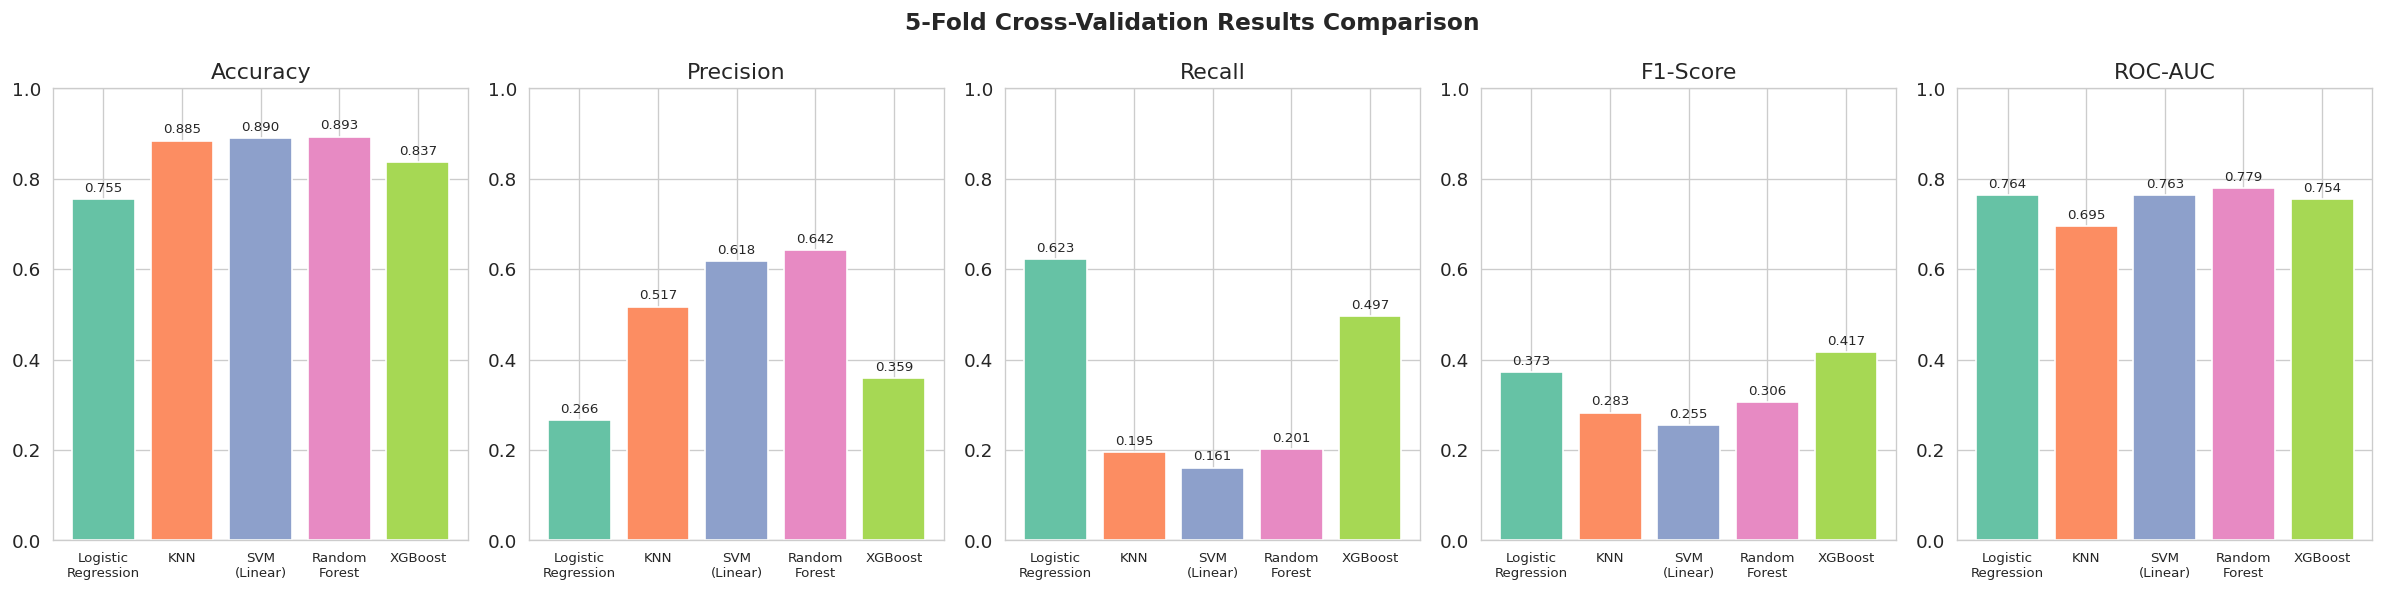

In [30]:
# Visualization: CV results comparison
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
model_names = list(cv_results.keys())

fig, axes = plt.subplots(1, 5, figsize=(20, 5))

palette = sns.color_palette('Set2', len(model_names))

for i, metric in enumerate(metrics_to_plot):
    vals = [cv_results[m][metric] for m in model_names]
    bars = axes[i].bar(range(len(model_names)), vals, color=palette)
    axes[i].set_title(metric)
    axes[i].set_xticks(range(len(model_names)))
    axes[i].set_xticklabels([n.replace(' ', '\n') for n in model_names], fontsize=8)
    axes[i].set_ylim(0, 1)
    for bar, val in zip(bars, vals):
        axes[i].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                     f'{val:.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('5-Fold Cross-Validation Results Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_cv_comparison.png', bbox_inches='tight')
plt.show()

### 4.2 Hyperparameter Tuning

In [31]:
# Hyperparameter tuning for Random Forest
print('=== Tuning Random Forest ===')
rf_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1))
])

rf_param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [5, 10, None],
    'classifier__min_samples_split': [2, 5]
}

rf_gs = GridSearchCV(
    rf_pipe, rf_param_grid, cv=cv, scoring='f1',
    n_jobs=2, verbose=1
)
rf_gs.fit(X_train, y_train)

print(f'Best RF params: {rf_gs.best_params_}')
print(f'Best RF F1 (CV): {rf_gs.best_score_:.4f}')

=== Tuning Random Forest ===
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best RF params: {'classifier__max_depth': 10, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}
Best RF F1 (CV): 0.4395


In [ ]:
# Hyperparameter tuning for XGBoost
print('=== Tuning XGBoost ===')
xgb_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
        eval_metric='logloss', random_state=42, n_jobs=-1
    ))
])

xgb_param_grid = {
    'classifier__n_estimators': [200, 400],
    'classifier__max_depth': [3, 5, 7],
    'classifier__learning_rate': [0.05, 0.1]
}

xgb_gs = GridSearchCV(
    xgb_pipe, xgb_param_grid, cv=cv, scoring='f1',
    n_jobs=2, verbose=1
)
xgb_gs.fit(X_train, y_train)

print(f'Best XGB params: {xgb_gs.best_params_}')
print(f'Best XGB F1 (CV): {xgb_gs.best_score_:.4f}')

In [ ]:
# Hyperparameter tuning for Logistic Regression
print('=== Tuning Logistic Regression ===')
lr_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42))
])

lr_param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10]
}

lr_gs = GridSearchCV(
    lr_pipe, lr_param_grid, cv=cv, scoring='f1',
    n_jobs=2, verbose=1
)
lr_gs.fit(X_train, y_train)

print(f'Best LR params: {lr_gs.best_params_}')
print(f'Best LR F1 (CV): {lr_gs.best_score_:.4f}')

In [ ]:
# Hyperparameter tuning for SVM (Linear)
# LinearSVC is much faster than kernel SVC on large datasets (O(n) vs O(n^2))
# We wrap it with CalibratedClassifierCV to get probability estimates
print('=== Tuning SVM (Linear) ===')
svm_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', CalibratedClassifierCV(
        LinearSVC(class_weight='balanced', max_iter=5000, random_state=42),
        cv=3
    ))
])

svm_param_grid = {
    'classifier__estimator__C': [0.01, 0.1, 1, 10]
}

svm_gs = GridSearchCV(
    svm_pipe, svm_param_grid, cv=cv, scoring='f1',
    n_jobs=2, verbose=1
)
svm_gs.fit(X_train, y_train)

print(f'Best SVM params: {svm_gs.best_params_}')
print(f'Best SVM F1 (CV): {svm_gs.best_score_:.4f}')

In [ ]:
# Hyperparameter tuning for KNN
print('=== Tuning KNN ===')
knn_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier())
])

knn_param_grid = {
    'classifier__n_neighbors': [3, 5, 7, 11],
    'classifier__weights': ['uniform', 'distance'],
    'classifier__metric': ['euclidean', 'manhattan']
}

knn_gs = GridSearchCV(
    knn_pipe, knn_param_grid, cv=cv, scoring='f1',
    n_jobs=2, verbose=1
)
knn_gs.fit(X_train, y_train)

print(f'Best KNN params: {knn_gs.best_params_}')
print(f'Best KNN F1 (CV): {knn_gs.best_score_:.4f}')

### 4.3 Test Set Evaluation (Tuned Models)

In [ ]:
# Collect best estimators
tuned_models = {
    'Logistic Regression': lr_gs.best_estimator_,
    'KNN': knn_gs.best_estimator_,
    'SVM (Linear)': svm_gs.best_estimator_,
    'Random Forest': rf_gs.best_estimator_,
    'XGBoost': xgb_gs.best_estimator_
}

test_results = {}

for name, model in tuned_models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    test_results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob),
        'y_pred': y_pred,
        'y_prob': y_prob
    }

# Display results table
results_df = pd.DataFrame({k: {m: v for m, v in v_dict.items() if m not in ['y_pred', 'y_prob']}
                           for k, v_dict in test_results.items()}).T
results_df = results_df.round(4)
print('=== Test Set Results (Tuned Models) ===')
display(results_df)

In [ ]:
# Visualization: Test results comparison
fig, ax = plt.subplots(figsize=(12, 6))

metrics_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(metrics_plot))
width = 0.15

for i, (name, res) in enumerate(test_results.items()):
    vals = [res[m] for m in metrics_plot]
    bars = ax.bar(x + i * width, vals, width, label=name, color=palette[i])

ax.set_xlabel('Metric')
ax.set_ylabel('Score')
ax.set_title('Test Set Performance Comparison (Tuned Models)')
ax.set_xticks(x + width * 2)
ax.set_xticklabels(metrics_plot)
ax.legend(loc='lower right')
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('fig_test_comparison.png', bbox_inches='tight')
plt.show()

### 4.4 Confusion Matrices

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(25, 4))

for i, (name, res) in enumerate(test_results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes'])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(name, fontsize=10)

plt.suptitle('Confusion Matrices - All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_confusion_matrices.png', bbox_inches='tight')
plt.show()

In [ ]:
# Print detailed classification reports
for name, res in test_results.items():
    print(f'\n{"="*50}')
    print(f'{name}')
    print(f'{"="*50}')
    print(classification_report(y_test, res['y_pred'], target_names=['No', 'Yes']))

### 4.5 ROC Curves

In [ ]:
plt.figure(figsize=(8, 6))

for i, (name, res) in enumerate(test_results.items()):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    auc_val = res['ROC-AUC']
    plt.plot(fpr, tpr, color=palette[i], lw=2, label=f'{name} (AUC = {auc_val:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC = 0.500)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - All Models')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig_roc_curves.png', bbox_inches='tight')
plt.show()

### 4.6 Feature Importance (Random Forest & XGBoost)

In [ ]:
# Get feature names after one-hot encoding
feature_names = (numeric_features +
                 list(rf_gs.best_estimator_.named_steps['preprocessor']
                      .named_transformers_['cat'].get_feature_names_out(categorical_features)))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Random Forest feature importance
rf_importance = rf_gs.best_estimator_.named_steps['classifier'].feature_importances_
rf_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': rf_importance})
rf_imp_df = rf_imp_df.sort_values('Importance', ascending=True).tail(15)

axes[0].barh(rf_imp_df['Feature'], rf_imp_df['Importance'], color='#2ecc71')
axes[0].set_title('Random Forest - Top 15 Features')
axes[0].set_xlabel('Importance')

# XGBoost feature importance
xgb_importance = xgb_gs.best_estimator_.named_steps['classifier'].feature_importances_
xgb_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': xgb_importance})
xgb_imp_df = xgb_imp_df.sort_values('Importance', ascending=True).tail(15)

axes[1].barh(xgb_imp_df['Feature'], xgb_imp_df['Importance'], color='#e67e22')
axes[1].set_title('XGBoost - Top 15 Features')
axes[1].set_xlabel('Importance')

plt.suptitle('Feature Importance Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_feature_importance.png', bbox_inches='tight')
plt.show()

## 5. Summary and Best Model Selection

In [ ]:
# Final comparison table
print('=' * 80)
print('FINAL RESULTS SUMMARY')
print('=' * 80)

summary = results_df.copy()
summary = summary.sort_values('F1-Score', ascending=False)
display(summary)

best_model_name = summary.index[0]
print(f'\nBest model by F1-Score: {best_model_name}')
print(f'  Accuracy:  {summary.loc[best_model_name, "Accuracy"]:.4f}')
print(f'  Precision: {summary.loc[best_model_name, "Precision"]:.4f}')
print(f'  Recall:    {summary.loc[best_model_name, "Recall"]:.4f}')
print(f'  F1-Score:  {summary.loc[best_model_name, "F1-Score"]:.4f}')
print(f'  ROC-AUC:   {summary.loc[best_model_name, "ROC-AUC"]:.4f}')

In [ ]:
# Tuned hyperparameters summary
print('=== Best Hyperparameters ===')
print(f'\nLogistic Regression: {lr_gs.best_params_}')
print(f'KNN: {knn_gs.best_params_}')
print(f'SVM (Linear): {svm_gs.best_params_}')
print(f'Random Forest: {rf_gs.best_params_}')
print(f'XGBoost: {xgb_gs.best_params_}')

In [ ]:
# Radar chart for final comparison
from matplotlib.patches import FancyBboxPatch

categories = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for i, (name, res) in enumerate(test_results.items()):
    vals = [res[m] for m in categories]
    vals += vals[:1]
    ax.plot(angles, vals, 'o-', linewidth=2, label=name, color=palette[i])
    ax.fill(angles, vals, alpha=0.1, color=palette[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)
ax.set_ylim(0, 1)
ax.set_title('Model Comparison Radar Chart', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.savefig('fig_radar_chart.png', bbox_inches='tight')
plt.show()

In [ ]:
# Export results to CSV for the paper
results_df.to_csv('results_test_set.csv')
cv_display.to_csv('results_cross_validation.csv')
print('Results exported to CSV files.')
print('Figures saved as PNG files.')
print('\nNotebook execution complete!')